In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os

In [3]:
a  = [1, 2]
b = [5, 4]
c = np.array([a, b])
print(c)
print(c.var(0))

[[1 2]
 [5 4]]
[4. 1.]


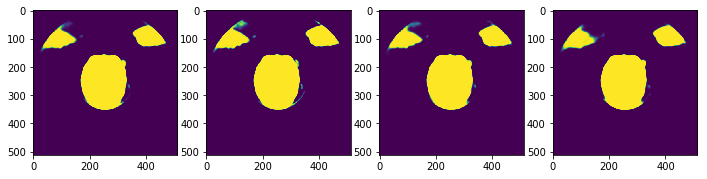

In [31]:
path = "/raid/zhuxihuan/data/body/88_aug_dropblock_FPN_DiceBCE_class_model_predict/BodyV2_17-BodyV2_17/"
plt.figure(figsize=(15, 15))
for i in range(4):
    img = np.load(path + f"pmask{i}.npy")
    plt.subplot(1, 5, i + 1)
    plt.imshow(img[230])
# d1 = np.load("/raid/zhuxihuan/data/body/88_aug_dropblock_FPN_DiceBCE_class_model_predict/BodyV2_17-BodyV2_17/pmask0.npy")
# print(d1.shape)
# plt.imshow(d1[0])

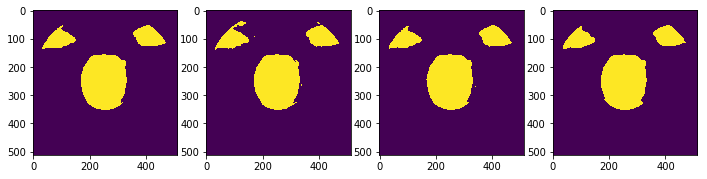

In [29]:
path = "/raid/zhuxihuan/data/body/88_aug_dropblock_FPN_DiceBCE_class_model_predict/BodyV2_17-BodyV2_17/"
plt.figure(figsize=(15, 15))
for i in range(4):
    img = np.load(path + f"pmask{i}.npy")
    plt.subplot(1, 5, i + 1)
    plt.imshow(img[230] > 0.5)

In [ ]:
index = 0
segThres = 0.5
indexThres = 0.1

In [ ]:
segPath = "/raid/zhuxihuan/data/body/mc_aug_dropblock88_BCE_pre_test5_dir/BodyV2_17-BodyV2_17/mean_mask.npy"
seg =  np.squeeze(np.load(segPath))[index] > segThres
print(np.max(seg), "HH", np.min(seg))
print(seg.shape)

In [ ]:
plt.imshow(seg, cmap="gray")

In [ ]:
entropyPath = f"/raid/zhuxihuan/data/body/mc_dropout_entropy/BodyV2_17-BodyV2_17/entropy{index}.npy"
entropySeg = np.load(entropyPath)
print(entropySeg.shape)
plt.imshow(entropySeg)

In [ ]:
entropySeg = entropySeg > indexThres
plt.imshow(entropySeg, cmap= "gray")

In [ ]:
tSegPath = "/raid/zhuxihuan/data/body/test_npy_data/BodyV2_17-BodyV2_17/mask.npy"
tSeg = np.squeeze(np.load(tSegPath))[index] > segThres
print(tSeg.shape)
print(np.max(tSeg), "HH", np.min(tSeg))
plt.imshow(tSeg, cmap="gray")

In [ ]:
error = (1 - tSeg)*(seg) + (1 - seg)* tSeg
print(error.shape)
print(np.max(error), "HH", np.min(error))
plt.imshow(error, cmap="gray")

In [ ]:
plt.imshow((1 - entropySeg )* seg, cmap="gray")

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
class SoftDiceLoss(nn.Module):
    def __init__(self, weight=None, size_average=True):
        super(SoftDiceLoss, self).__init__()
        
    def forward(self, probs, targets):
        #num = targets.size(0)
        smooth = 0.000000001
        
       # probs = torch.sigmoid(logits)
        m1 = probs.flatten()
       # print(m1.shape)
        m2 = targets.flatten()
        intersection = (m1 * m2)
        #print(intersection.shape)
        
        score = 2. * intersection.sum() / (m1.sum() + m2.sum() + smooth)
        #print(score.shape)
        #score = score.sum()
        return score

segPath = "/raid/zhuxihuan/data/body/mc_aug_dropblock88_BCE_pre_test5_dir/BodyV2_17-BodyV2_17/mean_mask.npy"
tSegPath = "/raid/zhuxihuan/data/body/test_npy_data/BodyV2_17-BodyV2_17/mask.npy"
def getAtlasCorrectionRate(segPath, tSegPath):
    segThres = 0.5
    indexThres = 0.9
    segg = np.squeeze(np.load(segPath))
    tSegg = np.squeeze(np.load(tSegPath))
    print(segg.shape)
    dice = 0
    for index in range(segg.shape[0]):
        #print(index)
        seg = segg[index] > segThres
        entropyPath = f"/raid/zhuxihuan/data/body/mc_dropout_atlas/BodyV2_17-BodyV2_17/atlas{index}.npy"
        entropySeg = np.load(entropyPath)
        entropySeg = entropySeg > indexThres
        tSeg = tSegg[index] > segThres
        error = (1 - tSeg)*(seg) + (1 - seg)* tSeg
        plt.imshow((1 - entropySeg )* seg + (entropySeg)*(1 - seg))
        print(SoftDiceLoss()((1 - entropySeg )* seg + (entropySeg)*(1 - seg) , error))
        dice = dice + SoftDiceLoss()((1 - entropySeg )* seg + (entropySeg)*(1 - seg) , error)
    print(dice/segg.shape[0])
getAtlasCorrectionRate(segPath, tSegPath)

In [ ]:
def getOtherCorrectionRate(segPath, tSegPath):
    segThres = 0.5
    indexThres = 0.1
    segg = np.squeeze(np.load(segPath))
    tSegg = np.squeeze(np.load(tSegPath))
    print(segg.shape)
    dice = 0
    for index in range(segg.shape[0]):
        print(index)
        #index = 0
        seg = segg[index] > segThres
        entropyPath = f"/raid/zhuxihuan/data/body/mc_dropout_entropy/BodyV2_17-BodyV2_17/entropy{index}.npy"
        entropySeg = np.load(entropyPath)
        entropySeg = entropySeg > indexThres
        #plt.imshow(entropySeg ,cmap="gray")
        tSeg = tSegg[index] > segThres
        error = (1 - tSeg)*(seg) + (1 - seg)* tSeg
        #plt.imshow(error, cmap="gray")
        plt.imshow((1 - entropySeg )* seg + (entropySeg)*(1 - seg), cmap="gray")
        dice = dice + SoftDiceLoss()((1 - entropySeg )* seg + (entropySeg)*(1 - seg) , error)
    print(dice/segg.shape[0])
getOtherCorrectionRate(segPath, tSegPath)